In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Newton's Second Law Smartphone Lab
Philip A. Sarkisian


## Introduction

Newton's Second Law of Motion (NII) states that the acceleration experienced by an object is equal to the net force acting on the object divided by its mass:
$$
\sum_{i=1}^{N} \vec{F}_i = m\vec{a}.
$$
The goal of this experiment is to determine the coefficient of kinetic friction, $\mu_k$, between a piece of paper on which a smartphone rests and the lab table. To measure the acceleration, we will use the *phyphox* smartphone application. In this experiment, the smartphone and paper will be attached to a daisy chain of rubber bands and briefly propelled across the lab table before being allowed to slide to a stop.

We will use the acceleration-versus-time data to identify the interval during which kinetic friction is the only significant force acting on the system in the direction of motion. During this interval, after the rubber bands are no longer exerting an appreciable force, Newton's Second Law predicts
$$
\sum_{i=1}^{N} F_{y_i}
= -f_k
= -\mu_k mg
= ma_y.
$$
Solving for the coefficient of kinetic friction gives
$$
\mu_k = \frac{-a_y}{g}.
$$
Thus, the coefficient of kinetic friction can be experimentally determined from the measured acceleration of the smartphone while it is sliding freely across the table.

By comparing a trial using the smartphone alone with a second trial in which additional mass is added to the smartphone, we also seek to determine whether the mass of the system has a measurable effect on the experimentally determined coefficient of kinetic friction.

## Procedure

A daisy chain of rubber bands was attached to a rigid metal rod clamped to the end of a lab bench. The smartphone was fastened to the final rubber band in the daisy chain and placed on top of a piece of paper to allow it to slide smoothly across the lab bench. The paper was used because most smartphone cases have relatively high coefficients of friction, which could inhibit smooth sliding and reduce the repeatability of the experiment.

With the smartphone resting on the paper, the phone was pulled backward a short distance, stretching the daisy chain of rubber bands and providing the restoring force necessary to propel the phone forward. The *phyphox* application was then used to record the phone's acceleration, beginning shortly before the phone was released and continuing until the phone came to a complete stop. Each trial lasted approximately 2 seconds.

This procedure was performed under two conditions: first with only the mass of the smartphone and then with an additional mass of $0.500~\mathrm{kg}$ added to the phone. The acceleration data from each trial were exported from *phyphox* as a CSV file and subsequently processed and analyzed using Python in a Jupyter Notebook. 

## Results
Immediately below are the tables for each trial.

In [2]:
data = pd.read_csv("Newtons_Second_Law.csv")
data.head()

,Time (s) Phone,Acceleration y (m/s^2) Phone,Time (s) Phone+Weight,Acceleration y (m/s^2) Phone+Weight,Unnamed: 4,Unnamed: 5
0,-0.000236,0.262255,0.001684,0.207169,NaN,NaN
1,0.009746,0.260458,0.011666,0.202379,NaN,NaN
2,0.019729,0.265847,0.021648,0.201930,NaN,NaN
3,0.029711,0.259411,0.031630,0.188608,NaN,NaN
4,0.039693,0.255519,0.041612,0.186812,NaN,NaN


In [3]:
# DataFrame for just the phone (without an added weight).

phone = data[["Time (s) Phone", "Acceleration y (m/s^2) Phone"]]
phone.head()

,Time (s) Phone,Acceleration y (m/s^2) Phone
0,-0.000236,0.262255
1,0.009746,0.260458
2,0.019729,0.265847
3,0.029711,0.259411
4,0.039693,0.255519


In [4]:
phone.dropna(inplace = True)
phone.head()

,Time (s) Phone,Acceleration y (m/s^2) Phone
0,-0.000236,0.262255
1,0.009746,0.260458
2,0.019729,0.265847
3,0.029711,0.259411
4,0.039693,0.255519


In [5]:
rename_dict = {"Time (s) Phone":"Time (s)",  "Acceleration y (m/s^2) Phone": "Acceleration (m/s^2)"}
phone.rename(columns = rename_dict, inplace = True)
phone.head()

,Time (s),Acceleration (m/s^2)
0,-0.000236,0.262255
1,0.009746,0.260458
2,0.019729,0.265847
3,0.029711,0.259411
4,0.039693,0.255519


In [6]:
# This is the DataFrame for the phone plus the added weight
phone_weight = data[["Time (s) Phone+Weight", "Acceleration y (m/s^2) Phone+Weight"]]
phone_weight.head()

,Time (s) Phone+Weight,Acceleration y (m/s^2) Phone+Weight
0,0.001684,0.207169
1,0.011666,0.202379
2,0.021648,0.201930
3,0.031630,0.188608
4,0.041612,0.186812


In [7]:
rename_dict = {"Time (s) Phone+Weight":"Time (s)",  "Acceleration y (m/s^2) Phone+Weight": "Acceleration (m/s^2)"}
phone_weight.rename(columns = rename_dict, inplace = True)
phone_weight.head()

,Time (s),Acceleration (m/s^2)
0,0.001684,0.207169
1,0.011666,0.202379
2,0.021648,0.201930
3,0.031630,0.188608
4,0.041612,0.186812


In [8]:
phone[phone['Acceleration (m/s^2)'] == max(phone['Acceleration (m/s^2)'])]

,Time (s),Acceleration (m/s^2)
52,0.518851,10.120155


In [9]:
coord = phone_weight[phone_weight['Acceleration (m/s^2)'] == max(phone_weight['Acceleration (m/s^2)'])]
coord

,Time (s),Acceleration (m/s^2)
40,0.400967,6.502927


Here, we'll make a scatterplot of each trial.

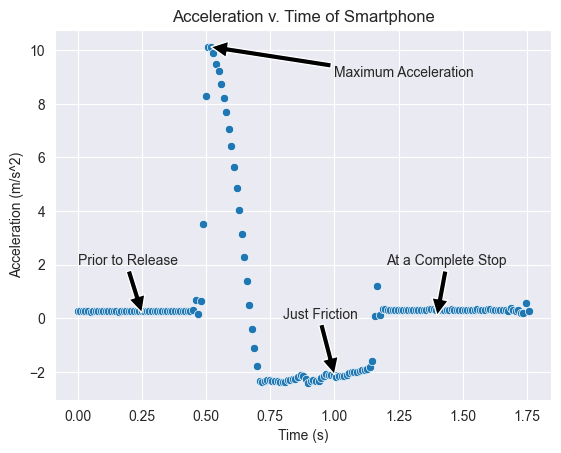

In [16]:
# Plotting the data from just the smartphone trial
fig, ax = plt.subplots()

sns.set_style("darkgrid")
sns.scatterplot(data = phone, x = 'Time (s)', y = 'Acceleration (m/s^2)', ax = ax)
ax.set_title("Acceleration v. Time of Smartphone")
ax.annotate(text = "Prior to Release", xy = (0.25, 0.2), xytext = (0, 2.0), arrowprops = dict(facecolor = "black", shrink=1.0))
ax.annotate(text = 'Maximum Acceleration', xy=(0.518851, 10.120155), xytext=(1, 9), arrowprops = dict(facecolor = "black", shrink=1.0))
ax.annotate(text = "Just Friction", xy = (1.0, -2.1), xytext = (0.8, 0.0), arrowprops = dict(facecolor = "black", shrink=1.0))
ax.annotate(text = "At a Complete Stop", xy = (1.4, 0.1), xytext = (1.2, 2), arrowprops = dict(facecolor = "black", shrink=1.0))
plt.show()

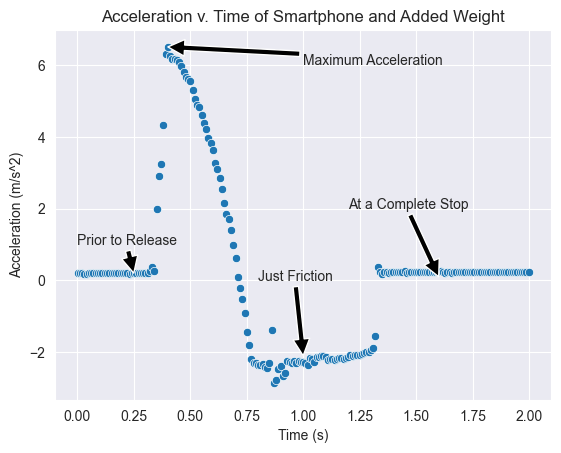

In [17]:
# Plotting the data from just the smartphone+weight trial
fig, ax = plt.subplots()

sns.set_style("darkgrid")
sns.scatterplot(data = phone_weight, x = 'Time (s)', y = 'Acceleration (m/s^2)', ax = ax)
ax.set_title("Acceleration v. Time of Smartphone and Added Weight")
ax.annotate(text = "Prior to Release", xy = (0.25, 0.2), xytext = (0, 1.0), arrowprops = dict(facecolor = "black", shrink=1.0))
ax.annotate(text = 'Maximum Acceleration', xy=(0.400967, 6.502927), xytext=(1, 6), arrowprops = dict(facecolor = "black", shrink=1.0))
ax.annotate(text = "Just Friction", xy = (1.0, -2.1), xytext = (0.8, 0.0), arrowprops = dict(facecolor = "black", shrink=1.0))
ax.annotate(text = "At a Complete Stop", xy = (1.6, 0.1), xytext = (1.2, 2), arrowprops = dict(facecolor = "black", shrink=1.0))
plt.show()

In [12]:
phone.set_index('Time (s)', inplace=True)
phone.head()

,Acceleration (m/s^2)
Time (s),
-0.000236,0.262255
0.009746,0.260458
0.019729,0.265847
0.029711,0.259411
0.039693,0.255519


In [13]:
phone_weight.set_index('Time (s)', inplace=True)
phone_weight.head()

,Acceleration (m/s^2)
Time (s),
0.001684,0.207169
0.011666,0.202379
0.021648,0.201930
0.031630,0.188608
0.041612,0.186812


In [14]:
mean_acceleration_phone = np.mean(phone[0.708517708233558:1.11779770825524]['Acceleration (m/s^2)'])
mu_k_phone = -mean_acceleration_phone/9.8
mu_k_phone

np.float64(0.2253418770084619)

In [15]:
mean_acceleration_phone_weight = np.mean(phone_weight[0.770303083350882:1.30933508335147]['Acceleration (m/s^2)'])
mu_k_phone_weight = -mean_acceleration_phone_weight/9.8
mu_k_phone_weight

np.float64(0.22728557716175357)

## Discussion of Results

In both graphs above, an initial period of near-zero acceleration can be observed at the beginning and end of the recorded time interval. These regions correspond to periods during which the smartphone was at rest: initially while the phone was being held prior to release and finally after the phone had come to a complete stop.

Immediately after the phone was released, the magnitude of its acceleration increased sharply as the restraining force exerted by the experimenter was removed and the stretched rubber bands accelerated the smartphone system forward. The acceleration quickly reached a maximum value. Following this peak, the acceleration decreased approximately linearly as the smartphone moved forward and the extension of the rubber-band chain decreased. This behavior is consistent with the elastic restoring force decreasing as the rubber bands approached their equilibrium length. Over the range of extensions used in this experiment, the rubber-band chain therefore exhibited approximately Hookean behavior.

In both trials, with and without the additional mass, a brief interval of approximately constant negative acceleration was observed after the rubber bands ceased exerting an appreciable force on the smartphone system. During this interval, kinetic friction was approximately the only horizontal force acting on the system. This portion of the motion therefore provided the most direct measurement of the effect of kinetic friction on the smartphone.

According to Newton's Second Law, the acceleration during this phase is

$$
ma_y = -f_k = -\mu_k mg,
$$

which gives

$$
\mu_k = \frac{-a_y}{g}.
$$

Thus, the mass of the system cancels from the expression, and the coefficient of kinetic friction is predicted to be independent of the system's mass. For each trial, the average acceleration was calculated over the interval in which the acceleration remained approximately constant and friction was the only significant horizontal force opposing the motion. The coefficient of kinetic friction was then calculated using the measured average acceleration and $g = 9.8~\mathrm{m/s^2}$.

The two trials produced similar values for the coefficient of kinetic friction. Within the resolution and experimental uncertainty of this experiment, adding $0.500~\mathrm{kg}$ to the smartphone did not produce a measurable change in the coefficient of kinetic friction. This result is consistent with the theoretical prediction that the coefficient of kinetic friction between two surfaces is independent of the mass of the sliding object.

## Conclusion

The purpose of this experiment was twofold: to determine the coefficient of kinetic friction between the printer paper supporting the smartphone and the surface of the lab bench, and to investigate whether changing the mass of the system produced a measurable change in the coefficient of kinetic friction. Within the precision of the measurements obtained in this experiment, the results were consistent with the predictions derived from Newton's Second Law and the kinetic-friction model.

The results of this experiment should, however, be interpreted cautiously because of several limitations in the experimental design. Most significantly, only two mass conditions were investigated, with only one trial performed for each condition. More conclusive results could be obtained by making several modifications while retaining the same general experimental design.

First, a larger range of masses should be tested. Measurements at several different masses would provide a stronger test of the prediction that the coefficient of kinetic friction is independent of the mass of the sliding system. Second, multiple trials should be performed for each mass. Repeated measurements would allow the mean coefficient of kinetic friction and its experimental uncertainty to be determined, making it possible to assess whether any differences between mass conditions are statistically meaningful. Third, the initial extension of the rubber-band chain and the release point should be standardized for every trial. In the present experiment, these quantities were estimated rather than precisely controlled, potentially introducing unnecessary trial-to-trial variation.

Despite these limitations, the experimentally determined coefficients of kinetic friction were similar for the two mass conditions. No measurable dependence of the coefficient of kinetic friction on the mass of the system was observed. The results are therefore consistent with the theoretical prediction that, for a given pair of surfaces, the coefficient of kinetic friction is approximately independent of the normal force over the range investigated in this experiment.